# 06 · Train an NPE posterior on the CL latents (Model B)

NPE (`sbi.inference.NPE`) with a MAF density estimator and an MLP embedding net, trained on the v1 + v2
training sets. The inferred parameters are `config.SBI_PARAMS`; the prior is a `BoxUniform` over them.

Reads `data/<run>/latents/train_v{1,2}.npz`. Writes `outputs/<run>/sbi_latents/posterior.pkl`,
`history.json` and `loss.png`. Next: `07_evaluate_SBI_Pk.ipynb`.

In [1]:
import config as cfg
from clmini import data, cl, sbi_tools, metrics, plots
print(f"run = {cfg.RUN_NAME} | data -> {cfg.DATA_DIR.relative_to(cfg.ROOT)} | outputs -> {cfg.OUT_DIR.relative_to(cfg.ROOT)}")
print("inferred parameters:", cfg.SBI_PARAMS)
cfg.SBI

run = full | data -> data/full | outputs -> outputs/full
inferred parameters: ['A', 'B', 'C']


{'hidden_features': 64,
 'num_transforms': 4,
 'num_blocks': 3,
 'embedding_layers': [32, 16, 8, 2],
 'batch_size': 128,
 'lr': 0.001,
 'validation_fraction': 0.2,
 'max_num_epochs': 2147483647,
 'stop_after_epochs': 20}

In [2]:
posterior, history = sbi_tools.train_npe(cfg, "latents")

[latents] training NPE on x (8192, 2) -> theta ['A', 'B', 'C'] (8192, 3)
 Neural network successfully converged after 95 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 95
        Best validation performance: -5.6746
        -------------------------
        


PosixPath('outputs/full/sbi_latents/loss.png')

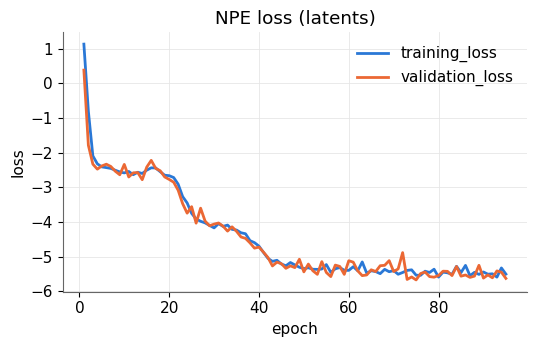

In [3]:
fig = plots.loss_history(history, title="NPE loss (latents)", keys=("training_loss", "validation_loss"))
metrics.save_fig(cfg, fig, "sbi_latents/loss")